In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5, EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns

2025-07-23 21:21:27.974031: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-23 21:21:28.927922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753284089.187864   35485 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753284089.257354   35485 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753284089.956347   35485 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# ------------------------------
# Data Preparation
# ------------------------------

def get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest')

    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    val_generator = val_test_datagen.flow_from_directory(
        val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    test_generator = val_test_datagen.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

    return train_generator, val_generator, test_generator

In [4]:
# ------------------------------
# Teacher Model - EfficientNetB5
# ------------------------------

def create_teacher_model(input_shape, num_classes, dropout_rate):
    base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [5]:
# ------------------------------
# Student Model - EfficientNetB0
# ------------------------------

def create_student_model(input_shape, num_classes, dropout_rate=0.3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True  # Fine-tune if desired

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [6]:
# ------------------------------
# Knowledge Distillation Logic
# ------------------------------

def distillation_loss(y_true, y_pred, teacher_pred, temperature, alpha):
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    soft_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(teacher_pred / temperature),
        tf.nn.softmax(y_pred / temperature))
    return alpha * hard_loss + (1 - alpha) * soft_loss

def train_student_with_distillation(student, teacher, train_gen, val_gen, epochs, temperature, alpha):
    optimizer = Adam()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        for i in range(len(train_gen)):
            x_batch, y_batch = train_gen[i]
            teacher_preds = teacher.predict(x_batch)

            with tf.GradientTape() as tape:
                student_preds = student(x_batch, training=True)
                loss = distillation_loss(y_batch, student_preds, teacher_preds, temperature, alpha)

            grads = tape.gradient(loss, student.trainable_variables)
            optimizer.apply_gradients(zip(grads, student.trainable_variables))

        student.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        val_loss, val_acc = student.evaluate(val_gen, verbose=0)
        print(f"Validation Accuracy: {val_acc:.4f}")

    return student

In [7]:
# ------------------------------
# Evaluation
# ------------------------------

def evaluate_model(model, test_generator, class_names):
    test_loss, test_acc = model.evaluate(test_generator)
    print("Test Accuracy:", test_acc)

    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes

    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    class_report = classification_report(true_classes, predicted_classes, target_names=class_names)
    precision = precision_score(true_classes, predicted_classes, average='weighted')
    recall = recall_score(true_classes, predicted_classes, average='weighted')
    f1 = f1_score(true_classes, predicted_classes, average='weighted')

    print("Confusion Matrix:\n", conf_matrix)
    print("\nClassification Report:\n", class_report)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 20})
    plt.xlabel('Predicted', fontsize=20)
    plt.ylabel('True', fontsize=20)
    plt.title('Confusion Matrix', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


I0000 00:00:1753284126.328296   35485 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21458 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
/mnt/d/FA011/tf_gpu_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1753284144.971001   35895 service.cc:152] XLA service 0x79a7e0020540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753284144.971046   35895 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-07-23 21:22:25.606537: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753284147.844243   35895 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-07-23 21:22:30.457646: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30395', 4 bytes spill stores, 4 bytes spill loads

2025-07-23 21:22:30.624992: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30395'

  1/101 ━━━━━━━━━━━━━━━━━━━━ 1:03:56 38s/step - accuracy: 0.3750 - loss: 1.6030

...

101/101 ━━━━━━━━━━━━━━━━━━━━ 92s 537ms/step - accuracy: 0.4215 - loss: 1.3816 - val_accuracy: 0.5826 - val_loss: 0.9653
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.6106 - loss: 0.9552 - val_accuracy: 0.6826 - val_loss: 0.7537
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.6485 - loss: 0.8860 - val_accuracy: 0.6522 - val_loss: 0.7984
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.6853 - loss: 0.8052 - val_accuracy: 0.7783 - val_loss: 0.5477
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6776 - loss: 0.7887 - val_accuracy: 0.7783 - val_loss: 0.5367
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.7227 - loss: 0.7198 - val_accuracy: 0.8348 - val_loss: 0.4396
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7302 - loss: 0.6942 - val_accuracy: 0.7913 - val_loss: 0.5409
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7401 - loss: 0.6614 - v

2025-07-23 21:43:36.061382: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 4 bytes spill stores, 4 bytes spill loads

2025-07-23 21:43:36.156472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 200 bytes spill stores, 536 bytes spill loads

2025-07-23 21:43:36.223823: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 116 bytes spill stores, 116 bytes spill loads

2025-07-23 21:43:39.987841: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 5616 bytes spill stores, 5612 bytes spill loads

2025-07-23 21:43:40.041996: I ex

Validation Accuracy: 0.3652

Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━

2025-07-23 23:23:45.059536: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 12 bytes spill stores, 12 bytes spill loads

2025-07-23 23:23:45.105468: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 8 bytes spill stores, 8 bytes spill loads

2025-07-23 23:23:45.188422: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 176 bytes spill stores, 524 bytes spill loads

2025-07-23 23:23:45.191235: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 8 bytes spill stores, 8 bytes spill loads

2025-07-23 23:23:45.230519: I external/l

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 350ms/step - accuracy: 0.7954 - loss: 1.0377
Test Accuracy: 0.8197425007820129
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step
Confusion Matrix:
 [[83 14  3  1  0]
 [19 69 11  0  0]
 [ 5 16 66  5  2]
 [ 2  0  1 84  2]
 [ 0  2  0  1 80]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       101
           1       0.68      0.70      0.69        99
           2       0.81      0.70      0.75        94
           3       0.92      0.94      0.93        89
           4       0.95      0.96      0.96        83

    accuracy                           0.82       466
   macro avg       0.83      0.83      0.83       466
weighted avg       0.82      0.82      0.82       466

Precision: 0.8205
Recall: 0.8197
F1 Score: 0.8190


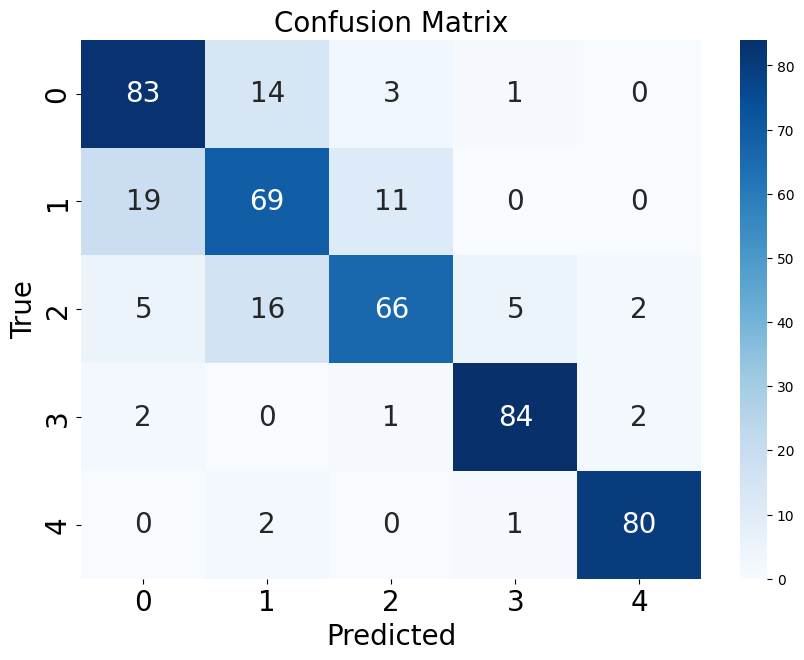

In [ ]:
# ------------------------------
# Main
# ------------------------------

if __name__ == "__main__":
    train_dir = '/mnt/d/FA019/new/SplittedDataset/train'
    val_dir = '/mnt/d/FA019/new/SplittedDataset/val'
    test_dir = '/mnt/d/FA019/new/SplittedDataset/test'

    img_size = (224, 224)
    input_shape = (img_size[0], img_size[1], 3)
    batch_size = 32
    dropout_rate = 0.3
    num_classes = len(os.listdir(train_dir))
    class_names = sorted(os.listdir(train_dir))

    train_gen, val_gen, test_gen = get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size)

    # Train teacher model
    teacher = create_teacher_model(input_shape, num_classes, dropout_rate)
    teacher.compile(optimizer=RMSprop(learning_rate=0.0003), loss='categorical_crossentropy', metrics=['accuracy'])
    teacher.fit(train_gen, epochs=100, validation_data=val_gen)

    # Create student model
    # Create Student using EfficientNetB0
    student = create_student_model(input_shape, num_classes, dropout_rate=0.3)









    # Train with distillation
    trained_student = train_student_with_distillation(
        student, teacher, train_gen, val_gen,
        epochs=100, temperature=3.0, alpha=0.3
    )

    # Final evaluation
    evaluate_model(trained_student, test_gen, class_names)